In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load house price dataset
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nWhat we're predicting — house prices:")
print(df['Price'].describe())

Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

What we're predicting — house prices:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


In [2]:
# Split features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)

# Measure performance
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model trained on {len(X_train)} houses")
print(f"Model tested on {len(X_test)} houses")
print(f"Mean Absolute Error: ${mae*100000:.0f}")
print(f"R2 Score: {r2:.2%}")

Model trained on 16512 houses
Model tested on 4128 houses
Mean Absolute Error: $53320
R2 Score: 57.58%


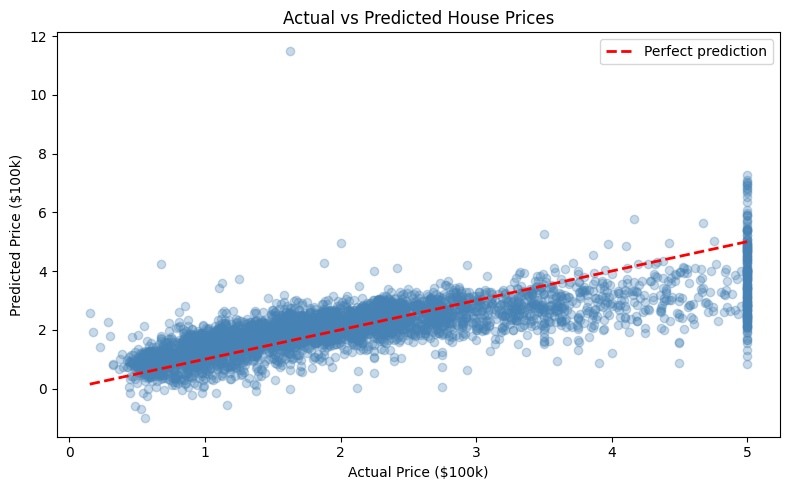


Feature impact on price:
      Feature    Impact
3   AveBedrms  0.783145
0      MedInc  0.448675
1    HouseAge  0.009724
4  Population -0.000002
5    AveOccup -0.003526
2    AveRooms -0.123323
6    Latitude -0.419792
7   Longitude -0.433708


In [3]:
# Visualize actual vs predicted prices
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

# Which features matter most
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
}).sort_values('Impact', ascending=False)

print("\nFeature impact on price:")
print(coefficients)

In [4]:
# Show some actual predictions vs real prices
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10] * 100000,
    'Predicted Price': predictions[:10] * 100000,
    'Difference': abs(y_test.values[:10] - predictions[:10]) * 100000
})
comparison = comparison.round(0)
print("Sample predictions vs actual prices:")
print(comparison.to_string(index=False))
print(f"\nAverage difference: ${comparison['Difference'].mean():,.0f}")

Sample predictions vs actual prices:
 Actual Price  Predicted Price  Difference
      47700.0          71912.0     24212.0
      45800.0         176402.0    130602.0
     500001.0         270966.0    229035.0
     218600.0         283893.0     65293.0
     278000.0         260466.0     17534.0
     158700.0         201175.0     42475.0
     198200.0         264550.0     66350.0
     157500.0         216876.0     59376.0
     340000.0         274075.0     65925.0
     446600.0         391561.0     55039.0

Average difference: $75,584
